In [6]:
from amplitude_analysis import *
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
%matplotlib inline

In [2]:
def json_dir_to_df(dir: Path) -> pd.DataFrame:
    return pd.DataFrame([json.loads(file.read_text()) for file in dir.glob("*.json")])


name_to_lattice = {lattice.get_cache_id(): lattice for lattice in lattices}


In [3]:
df = json_dir_to_df(experiment_dir)

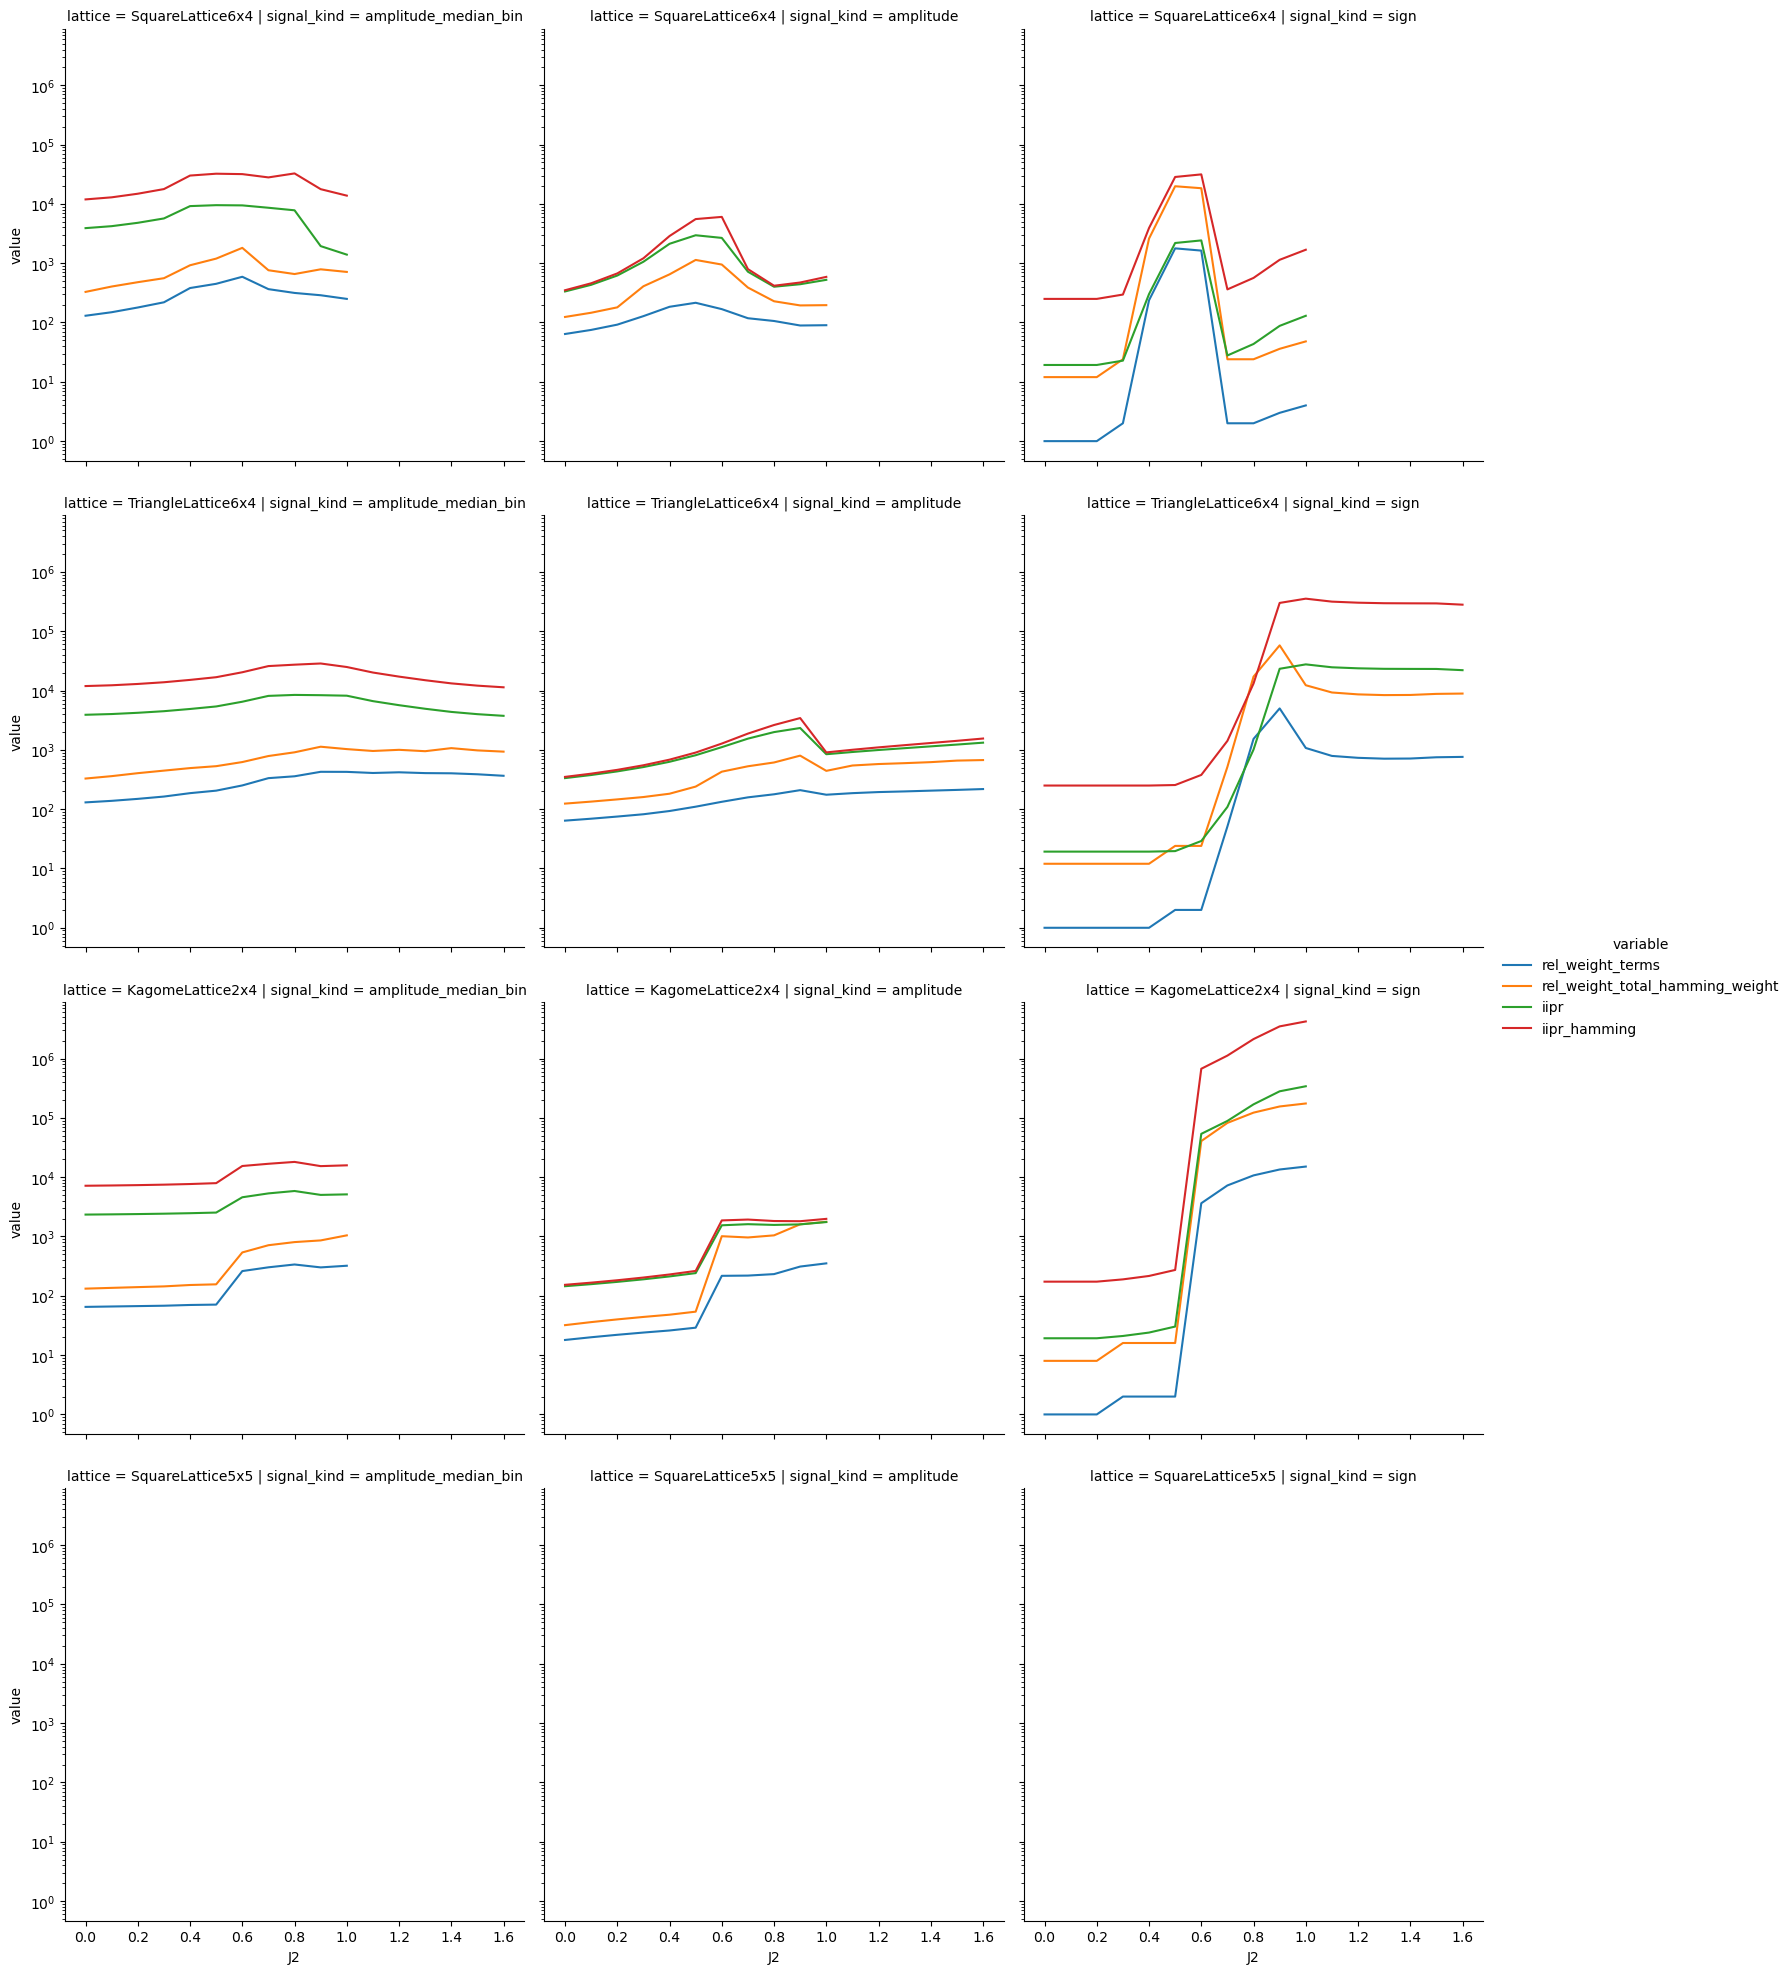

In [9]:
sns.relplot(
    df.assign(
        iipr=lambda df: 1.0 / df["ipr"], iipr_hamming=lambda df: 1.0 / df["ipr_hamming"]
    ).melt(
        id_vars=["J2", "lattice", "signal_kind"],
        value_vars=["rel_weight_terms", "rel_weight_total_hamming_weight", "iipr", "iipr_hamming"],
    ),
    x="J2",
    y="value",
    hue="variable",
    col="signal_kind",
    row="lattice",
    kind="line",
).set(yscale='log')
